In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/llm_datasets/marathi/"

In [ ]:
import os
os.makedirs(SAVE_PATH, exist_ok=True)

In [ ]:
import requests

url = "https://huggingface.co/datasets/ai4bharat/IndicCorpV2/resolve/main/data/mr.txt?download=1"

MAX_LINES = 1_000_000
OUT_FILE = "/content/drive/MyDrive/llm_datasets/marathi/mr_sample_1M.txt"

response = requests.get(url, stream=True)

with open(OUT_FILE, "w", encoding="utf-8") as f:
    for i, line in enumerate(response.iter_lines()):
        if i >= MAX_LINES:
            break
        if line:
            f.write(line.decode("utf-8").strip() + "\n")

print("Sampling complete.")

Sampling complete.


In [ ]:
INDIC_SAMPLE = "/content/drive/MyDrive/llm_datasets/marathi/mr_sample_1M.txt"
OUTPUT_FILE = "/content/drive/MyDrive/llm_datasets/marathi/marathi_corpus_stage1.txt"

In [ ]:
FILE = "/content/drive/MyDrive/llm_datasets/marathi/mr_sample_1M.txt"

with open(FILE, encoding="utf-8") as f:
    for i in range(20):
        line = f.readline()
        if not line:
            break
        print(f"[Line {i+1}] {repr(line)}")

[Line 1] 'ऊती संवर्धन तंत्राचे अनेक उपयोग आहेत. या तंत्राचा उपयोग विशेषकरून जीवशास्त्र व वैद्यकशास्त्रात होतो. वयोवृद्धी, पोषण, लसनिर्मिती, जन्मजात रोगांचे निदान, इंद्रियांचे रोपण, कर्करोग संशोधन व गर्भपोषण या क्षेत्रांत ऊती संवर्धन तंत्र प्रामुख्याने वापरले जाते. पेशींच्या चयापचयावर एखाद्या घटकाचा परिणाम पाहणे, सामान्य किंवा कर्करोगाच्या पेशींवर औषधांचा होणारा परिणाम पाहणे, प्रयोगशाळेत त्वचा तयार करणे इ. बाबी ऊती संवर्धनामुळे शक्य झाल्या आहेत. भाजलेल्या रुग्णाच्या त्वचारोपणासाठी ऊती संवर्धनाद्वारे निर्माण केलेली त्वचा वापरली जाते.\n'
[Line 2] 'शहरातील माध्यमिक विभागाच्या शाळा ३ जानेवारीपर्यंत विद्यार्थ्यांसाठी बंद ठेवण्यात येणार आहेत. मात्र, शिक्षकांना शा\u200cळेत जाणे अनिवार्य केले आहे. त्यामुळे शिक्षक, शिक्षकेतर कर्मचाऱ्यांना कोरोना तपासणी सक्तीची केली आहे. सोमवारी ५९८ शिक्षकांची तपासणी करण्यात आली. रविवारी २९८ शिक्षकांची तपासणी झाली होती. त्यामध्ये १८ जणांना कोरोनाची बाधा झाल्याचे आढळले.  आतापर्यंत शंभरपेक्षा अधिक शिक्षक, शिक्षकेतर कर्मचारी पॉझिटिव्ह आढळले आहेत.\n'
[Line 3] 'राणे य

In [ ]:
raw_count = sum(1 for _ in open(INDIC_SAMPLE, encoding="utf-8"))
print("Raw lines in sampled file:", raw_count)

Raw lines in sampled file: 500000


In [ ]:
with open(INDIC_SAMPLE, "rb") as f:
    raw = f.read()

text = raw.decode("utf-8")   # 👈 THIS IS THE FIX

lines = text.split("\n")

for i in range(20):
    print(lines[i])

ऊती संवर्धन तंत्राचे अनेक उपयोग आहेत. या तंत्राचा उपयोग विशेषकरून जीवशास्त्र व वैद्यकशास्त्रात होतो. वयोवृद्धी, पोषण, लसनिर्मिती, जन्मजात रोगांचे निदान, इंद्रियांचे रोपण, कर्करोग संशोधन व गर्भपोषण या क्षेत्रांत ऊती संवर्धन तंत्र प्रामुख्याने वापरले जाते. पेशींच्या चयापचयावर एखाद्या घटकाचा परिणाम पाहणे, सामान्य किंवा कर्करोगाच्या पेशींवर औषधांचा होणारा परिणाम पाहणे, प्रयोगशाळेत त्वचा तयार करणे इ. बाबी ऊती संवर्धनामुळे शक्य झाल्या आहेत. भाजलेल्या रुग्णाच्या त्वचारोपणासाठी ऊती संवर्धनाद्वारे निर्माण केलेली त्वचा वापरली जाते.
शहरातील माध्यमिक विभागाच्या शाळा ३ जानेवारीपर्यंत विद्यार्थ्यांसाठी बंद ठेवण्यात येणार आहेत. मात्र, शिक्षकांना शा‌ळेत जाणे अनिवार्य केले आहे. त्यामुळे शिक्षक, शिक्षकेतर कर्मचाऱ्यांना कोरोना तपासणी सक्तीची केली आहे. सोमवारी ५९८ शिक्षकांची तपासणी करण्यात आली. रविवारी २९८ शिक्षकांची तपासणी झाली होती. त्यामध्ये १८ जणांना कोरोनाची बाधा झाल्याचे आढळले.  आतापर्यंत शंभरपेक्षा अधिक शिक्षक, शिक्षकेतर कर्मचारी पॉझिटिव्ह आढळले आहेत.
राणे यांनी शिवसेनेच्या मंत्र्यावर केलेल्या आरोप

In [ ]:
file_path = INDIC_SAMPLE  # path to mr_sample_1M.txt

def devanagari_ratio(line):
    total = len(line)
    if total == 0:
        return 0
    dev = sum(1 for ch in line if '\u0900' <= ch <= '\u097F')
    return dev / total

ratios = []   # store devanagari percentages

with open(file_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if len(line) < 5:
            continue
        ratios.append(devanagari_ratio(line))

print("Total lines analyzed:", len(ratios))

Total lines analyzed: 500000


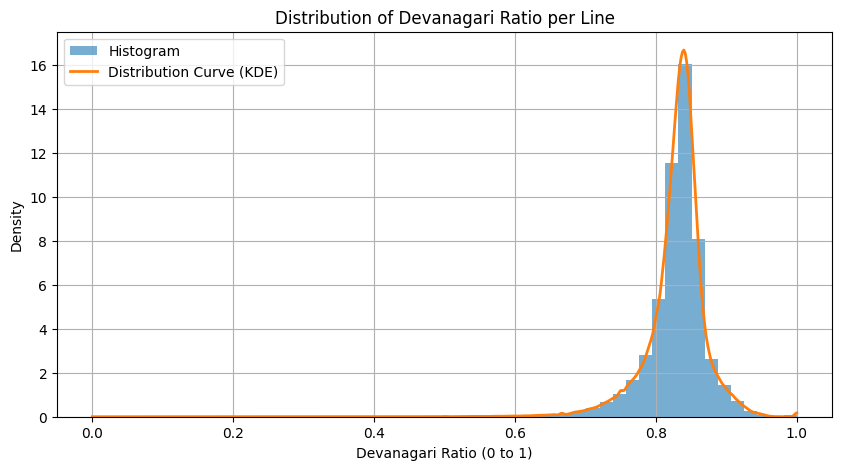

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Convert ratios to numpy array
data = np.array(ratios)

# Create KDE (smooth distribution curve)
kde = gaussian_kde(data)
x_vals = np.linspace(0, 1, 500)
kde_vals = kde(x_vals)

plt.figure(figsize=(10, 5))

# Histogram
plt.hist(data, bins=50, density=True, alpha=0.6, label="Histogram")

# KDE curve
plt.plot(x_vals, kde_vals, linewidth=2, label="Distribution Curve (KDE)")

plt.title("Distribution of Devanagari Ratio per Line")
plt.xlabel("Devanagari Ratio (0 to 1)")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()

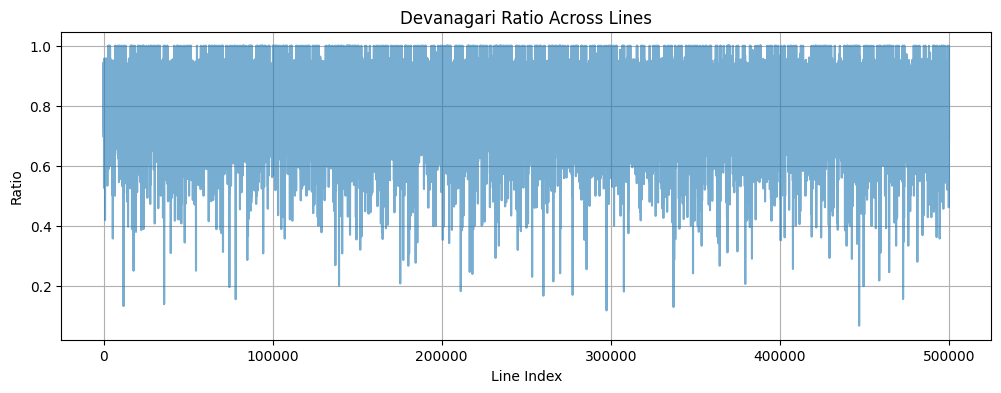

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(ratios, alpha=0.6)
plt.title("Devanagari Ratio Across Lines")
plt.xlabel("Line Index")
plt.ylabel("Ratio")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

ratios_np = np.array(ratios)

print("Average Devanagari %:", np.mean(ratios_np))
print("Median Devanagari %:", np.median(ratios_np))
print("Min:", np.min(ratios_np))
print("Max:", np.max(ratios_np))

Average Devanagari %: 0.8295249024862205
Median Devanagari %: 0.8349753694581281
Min: 0.06666666666666667
Max: 1.0


In [ ]:
import re

# Allowed characters:
# - Devanagari: \u0900-\u097F
# - Zero Width Joiner / Non-Joiner: \u200C \u200D
# - Numbers: 0-9
# - Basic punctuation and symbols
ALLOWED_PATTERN = r"[^\u0900-\u097F\u200C\u200D0-9 .,!?\"'():;\-\+\*/%=]"

def clean_line(line):
    line = line.strip()

    # Remove URLs
    line = re.sub(r"http\S+|www\.\S+", "", line)

    # Remove emojis & disallowed characters (but keep ZWJ/ZWNJ!)
    line = re.sub(ALLOWED_PATTERN, "", line)

    # Normalize spaces
    line = re.sub(r"\s+", " ", line)

    return line.strip()

def is_marathi(line):
    # line must contain at least one Devanagari char
    return bool(re.search(r"[\u0900-\u097F]", line))

In [ ]:
all_lines = []
raw_count = 0

with open(INDIC_SAMPLE, encoding="utf-8") as f:
    for line in f:
        raw_count += 1
        cleaned = clean_line(line)

        # Keep only meaningful Marathi lines
        if len(cleaned) > 15 and is_marathi(cleaned):
            all_lines.append(cleaned)

print("Raw lines:", raw_count)
print("Clean Marathi lines:", len(all_lines))

Raw lines: 500000
Clean Marathi lines: 492890


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import random
random.shuffle(all_lines)

In [ ]:
OUTPUT_FILE = "/content/drive/MyDrive/llm_datasets/marathi/mr_clean_500k.txt"

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for line in all_lines:
        f.write(line + "\n")

print("Saved cleaned & shuffled dataset to:", OUTPUT_FILE)
print("Total lines written:", len(all_lines))

Saved cleaned & shuffled dataset to: /content/drive/MyDrive/llm_datasets/marathi/mr_clean_500k.txt
Total lines written: 492890


In [ ]:
for i in range(10):
    print(all_lines[i])

यमुना खादर भागात फक्त बोटीनेच जाता येतं. इथे मुख्यमंत्र्यांच्या जाहीरातीही पोहोचल्या नाहीत. मात्र आमच्या लसी पोहोचल्या आहेत, असं ट्वीट गौतम गंभीर याने केलं आहे. तसेच असा हॅशटॅग टाकला आहे. गौतम गंभीर यांच्या उपस्थितीत यमुना खादर भागातील जनतेचं लसीकरण करण्यात आलं. यावेळी त्यांच्यासोबत काही भाजपा कार्यकर्ते उपस्थित होते.
या पाणीपुरी डिस्पेन्सरमुळे सुक्या पुरीमध्ये ऑटोमॅटीक पाणी आणि सारण भरलं जाईल. त्यामुळे पाण्यात हात बुडवून ती सर्व्ह करण्याचा किसळवाणा प्रकार टाळता येईल. या डिस्पेन्सरमुळे ग्राहकांना हायजिनिक पाणीपुरीचा आस्वाद घेता येणार आहे. फक्त या डिस्पेन्सरमध्ये सारण भरण्यासाठी एका व्यक्तीची आवश्यकता असणार आहे. त्याचबरोबर एका व्यक्तीने किती पाणीपुरी खालल्या त्याचा हिशोब देखील ही मशीन ठेवणार आहे.
तमिळानाडूत 45 वर्षांवरील सर्वांना लस उपलब्ध नाही. त्यांना पहिला डोस मिळण्यातच अडचण निर्माण झाली असून अगदी थोड्या लोकांना लसीचा दुसरा डोस मिळाला आहे. 18 ते 44 वयोगटातील कोणालाच लस उपलब्ध नाही अशी स्थिती आहे. अन्य राज्यातही अशीच परिस्थिती आहे. पंतप्रधान आणि आरोग्यमंत्री कोणतीच जबाबदारी घ्यायला तय

In [ ]:
file_path = OUTPUT_FILE  # path to mr_clean_500k.txt

def devanagari_ratio(line):
    total = len(line)
    if total == 0:
        return 0
    dev = sum(1 for ch in line if '\u0900' <= ch <= '\u097F')
    return dev / total

cleaned_ratios = []   # store devanagari percentages

with open(file_path, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if len(line) < 5:
            continue
        cleaned_ratios.append(devanagari_ratio(line))

print("Total lines analyzed:", len(cleaned_ratios))

Total lines analyzed: 492890


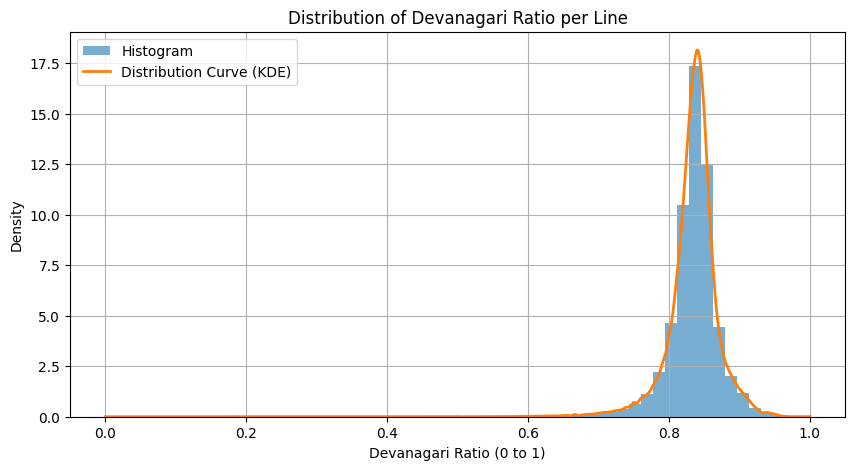

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Convert ratios to numpy array
data = np.array(cleaned_ratios)

# Create KDE (smooth distribution curve)
kde = gaussian_kde(data)
x_vals = np.linspace(0, 1, 500)
kde_vals = kde(x_vals)

plt.figure(figsize=(10, 5))

# Histogram
plt.hist(data, bins=50, density=True, alpha=0.6, label="Histogram")

# KDE curve
plt.plot(x_vals, kde_vals, linewidth=2, label="Distribution Curve (KDE)")

plt.title("Distribution of Devanagari Ratio per Line")
plt.xlabel("Devanagari Ratio (0 to 1)")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()